# ***APRENDIZAJE AUTOMÁTICO - CLASE N°2***
## Ejercicio N°2 - Car information dataset.

### Cargar el conjunto de datos en una estructura adecuada para su manipulación.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Definir la URL 'Raw' del archivo dentro de la carpeta Ejercicio-2 de Github
url_raw = "https://raw.githubusercontent.com/arieltunon74/Aprendizaje_Automatico_2026/main/Clase2/Ejercicio-2/Automobile.csv"
# Cargar el conjunto de datos
df = pd.read_csv(url_raw)
print("\n" * 2)

print("--- Primeros 5 registros ---")
display(df.head())
print("\n" * 3)


print("\n- ANALISIS DESCRIPTIVO")
print("\n--- Información del DataFrame (Tipos de datos y nulos) ---")
print(" " * 10)
df.info()
print("\n" * 2)
print("\n--- Dimensiones del dataset Automobile.CSV ---")
print(" " * 10)
# Muestra el número total de (filas, columnas)
print("Dimensiones (filas, columnas):", df.shape)
# Número total de filas
print("Cantidad de filas:", len(df))
# Número total de elementos (filas x columnas)
print("Total de elementos:", df.size)
print("\n" * 2)



# Verificacion de outliers
# Seleccionar variables numéricas
df_numeric = df.select_dtypes(include=[np.number])

# Calcular cuartiles e IQR
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

# Definir límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar máscara booleana de outliers
outliers_mask = (df_numeric < limite_inferior) | (df_numeric > limite_superior)

# Mostrar cantidad de outliers por cada columna numérica
print("Outliers detectados por variable:")
print(outliers_mask.sum()[outliers_mask.sum() > 0])






--- Primeros 5 registros ---


,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa
4,ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa







- ANALISIS DESCRIPTIVO

--- Información del DataFrame (Tipos de datos y nulos) ---
          
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          398 non-null    object 
 1   mpg           398 non-null    float64
 2   cylinders     398 non-null    int64  
 3   displacement  398 non-null    float64
 4   horsepower    392 non-null    float64
 5   weight        398 non-null    int64  
 6   acceleration  398 non-null    float64
 7   model_year    398 non-null    int64  
 8   origin        398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB




--- Dimensiones del dataset Automobile.CSV ---
          
Dimensiones (filas, columnas): (398, 9)
Cantidad de filas: 398
Total de elementos: 3582



Outliers detectados por variable:
mpg              1
horsepower      10
acceleration     7
dtype: int64


### Gráfico de dispersion para visualizar las relaciones entre los pares 'mpg' y 'weight'.

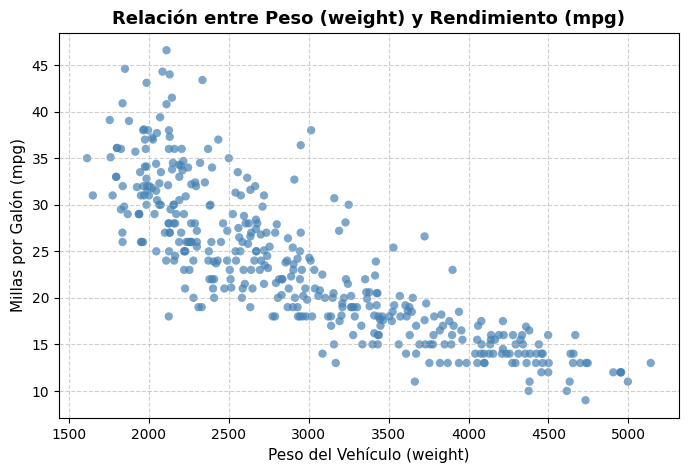


 Correlación negativa:

- A mayor peso (weight), menor es el rendimiento de combustible (mpg).





In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar el dataset
url_raw = "https://raw.githubusercontent.com/arieltunon74/Aprendizaje_Automatico_2026/main/Clase2/Ejercicio-2/Automobile.csv"
df = pd.read_csv(url_raw, na_values='?')
# 2. Configurar y crear el gráfico de dispersión
plt.figure(figsize=(8, 5))
plt.scatter(df['weight'], df['mpg'], color='steelblue', alpha=0.7, edgecolors='none')
# 3. Personalización del gráfico
plt.title('Relación entre Peso (weight) y Rendimiento (mpg)', fontsize=13, fontweight='bold')
plt.xlabel('Peso del Vehículo (weight)', fontsize=11)
plt.ylabel('Millas por Galón (mpg)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
# 4. Mostrar el gráfico
plt.show()

print("\n Correlación negativa:")
print("\n- A mayor peso (weight), menor es el rendimiento de combustible (mpg).")
print("\n" * 2)

### Histograma del consumo de combustible (Cmpg) para analizar su distribución.

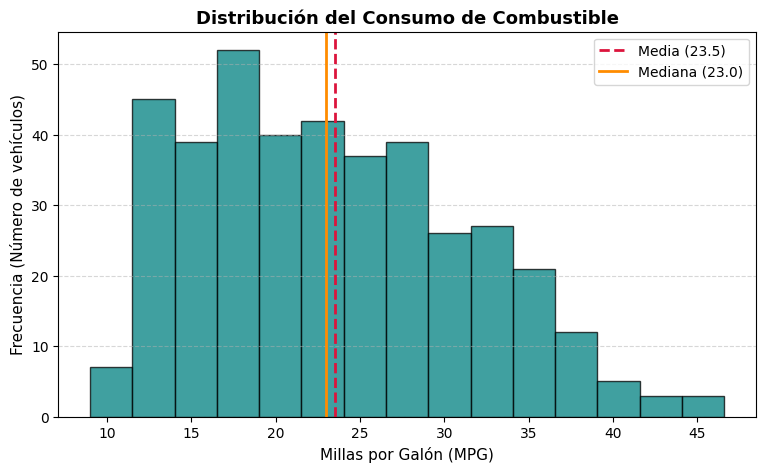


 Se percibe un sesgo a la derecha:

- La mayoría de los vehículos se concentran en rangos de consumo bajo a moderado (15 a 30 mpg), con una minoría de vehículos de alta eficiencia que extienden la cola hacia la derecha.





In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el dataset
url_raw = "https://raw.githubusercontent.com/arieltunon74/Aprendizaje_Automatico_2026/main/Clase2/Ejercicio-2/Automobile.csv"
df = pd.read_csv(url_raw, na_values='?')

# Detectar el nombre exacto de la columna de rendimiento
col_mpg = 'mpg' if 'mpg' in df.columns else ('city-mpg' if 'city-mpg' in df.columns else 'Cmpg')

# Crear el histograma
plt.figure(figsize=(9, 5))
n, bins, patches = plt.hist(df[col_mpg].dropna(), bins=15, color='teal', edgecolor='black', alpha=0.75)

# Agregar líneas para Media y Mediana
media = df[col_mpg].mean()
mediana = df[col_mpg].median()

plt.axvline(media, color='crimson', linestyle='--', linewidth=2, label=f'Media ({media:.1f})')
plt.axvline(mediana, color='darkorange', linestyle='-', linewidth=2, label=f'Mediana ({mediana:.1f})')

# Personalización y etiquetas
plt.title('Distribución del Consumo de Combustible', fontsize=13, fontweight='bold')
plt.xlabel('Millas por Galón (MPG)', fontsize=11)
plt.ylabel('Frecuencia (Número de vehículos)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()

# Mostrar el gráfico
plt.show()

print("\n Se percibe un sesgo a la derecha:")
print("\n- La mayoría de los vehículos se concentran en rangos de consumo bajo a moderado (15 a 30 mpg), con una minoría de vehículos de alta eficiencia que extienden la cola hacia la derecha.")
print("\n" * 2)

### Diagrama de caja (boxplot) de las caracteristicas 'cylinders' y 'origin' para identificar posibles valores atipicos.


-Para la variable origin: 

- Conversión de valores categóricos a numéricos con método One-Hot Encoding (Recomendado para Machine Learning)



    origin  origin_num
0      usa           1
14   japan           2
19  europe           3






/tmp/ipykernel_1635/2903620106.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


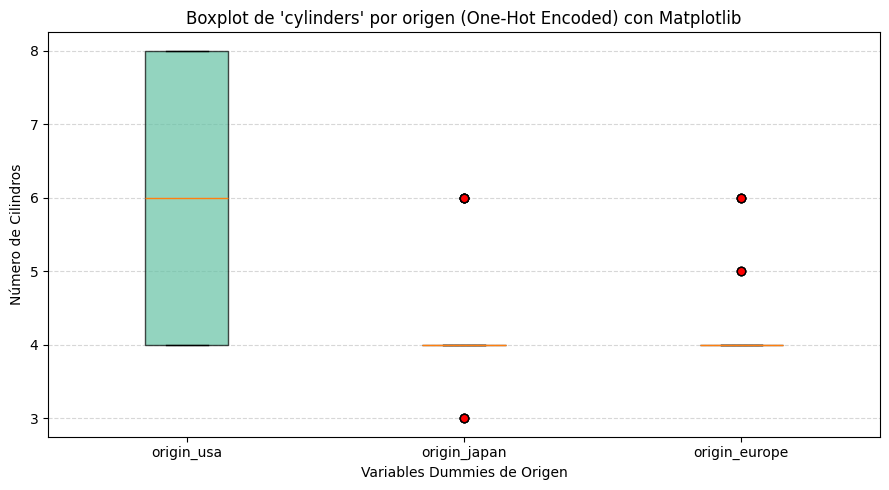

In [50]:

import matplotlib.pyplot as plt
import pandas as pd
print("\n-Para la variable origin: ")
print("\n- Conversión de valores categóricos a numéricos con método One-Hot Encoding (Recomendado para Machine Learning)")
print("\n" * 2)

# 1. Definir el mapa de conversión
mapa_origen = {'usa': 1, 'japan': 2, 'europe': 3}

# 2. Crear la nueva columna numérica o reemplazar la existente
# This part assumes df is already loaded from previous cells.
df['origin_num'] = df['origin'].map(mapa_origen)

# Comprobar el resultado
print(df[['origin', 'origin_num']].drop_duplicates())
print("\n" * 3)


# 1. Cargar el dataset
url_raw = "https://raw.githubusercontent.com/arieltunon74/Aprendizaje_Automatico_2026/main/Clase2/Ejercicio-2/Automobile.csv"
df_plot = pd.read_csv(url_raw, na_values='?') # Use a new df_plot to avoid conflicting with the main 'df'

# 2. Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df_plot, columns=['origin'], dtype=int)

# 3. Filtrar los valores de 'cylinders' para cada categoría dummy
usa_cyl = df_encoded[df_encoded['origin_usa'] == 1]['cylinders']
japan_cyl = df_encoded[df_encoded['origin_japan'] == 1]['cylinders']
europe_cyl = df_encoded[df_encoded['origin_europe'] == 1]['cylinders']

# 4. Crear la figura con Matplotlib
plt.figure(figsize=(9, 5))

box = plt.boxplot(
    [usa_cyl, japan_cyl, europe_cyl],
    labels=['origin_usa', 'origin_japan', 'origin_europe'],
    patch_artist=True,  # Permite colorear los rectángulos
    flierprops=dict(
        marker='o', markerfacecolor='red', markeredgecolor='black', markersize=6
    ),
)

# Personalizar colores de las cajas
colors = ['#66c2a5', '#fc8d62', '#8da0cb']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Formato y etiquetas
plt.title("Boxplot de 'cylinders' por origen (One-Hot Encoded) con Matplotlib")
plt.xlabel("Variables Dummies de Origen")
plt.ylabel("Número de Cilindros")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Japón: Muestra outliers en 3 cilindros (motores rotativos) y en 6 cilindros.

Europa: Muestra outliers en 5 cilindros y 6 cilindros.

EE. UU.: No presenta outliers ya que sus valores abarcan homogéneamente de 4 a 8 cilindros.

### Gráfico de barras que muestra la distribución de automóviles según su año de modelo

### ('model_year') y Origen ('origin').

<Figure size 1200x600 with 0 Axes>

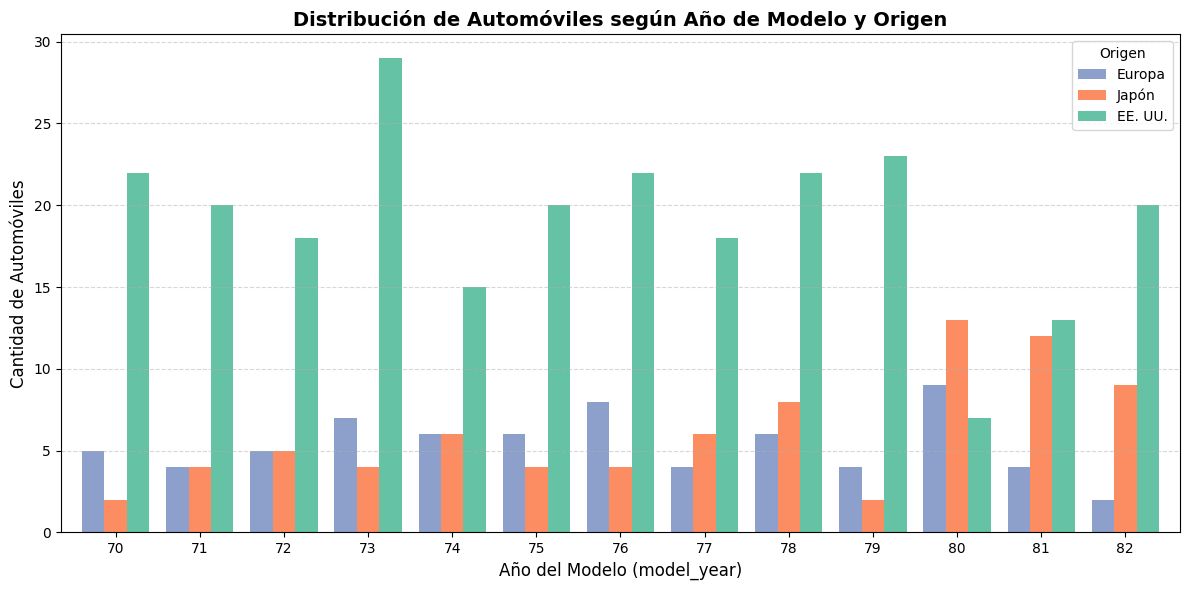

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

# Cargar el dataset
url_raw = "https://raw.githubusercontent.com/arieltunon74/Aprendizaje_Automatico_2026/main/Clase2/Ejercicio-2/Automobile.csv"
df = pd.read_csv(url_raw, na_values='?')

# 2. Crear la tabla cruzada de frecuencias (Conteo por año y origen)
conteo_año_origen = pd.crosstab(df['model_year'], df['origin'])

# 3. Crear el gráfico de barras agrupadas
plt.figure(figsize=(12, 6))
ax = conteo_año_origen.plot(
    kind='bar', figsize=(12, 6), width=0.8, color=['#8da0cb', '#fc8d62', '#66c2a5']
)

# 4. Personalización del gráfico
plt.title(
    'Distribución de Automóviles según Año de Modelo y Origen',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Año del Modelo (model_year)', fontsize=12)
plt.ylabel('Cantidad de Automóviles', fontsize=12)
plt.xticks(rotation=0)  # Mantener los años horizontales
plt.legend(title='Origen', labels=['Europa', 'Japón', 'EE. UU.'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## ***El gráfico de barras agrupadas representa la evolución temporal de la producción/muestra de vehículos según su país o región de origen entre los años 1970 y 1982.***

### Permite analizar visualmente cómo cambia la composición del mercado automotriz a lo largo del tiempo:

### *Evidencia el dominio del mercado estadounidense (usa)*

La crisis del petróleo y el cambio en 1980: En 1980 ocurre un cambio histórico evidente: los autos japoneses (japan) superan por primera vez a los estadounidenses en el dataset (13 modelos de Japón vs. 7 de EE. UU.).